### CTR Prediction Model Training
# 
#### **Author**: Praveen Kumar  
#### **Date**: September 2026
# 
#### Training and evaluating LightGBM model for CTR prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
df = pd.read_csv('../data/final_data.csv')
X = df.drop('Clicked', axis=1)
y = df['Clicked']

print(f"Dataset shape: {df.shape}")
print(f"Features: {X.columns.tolist()}")

Dataset shape: (10000, 14)
Features: ['Age', 'Income', 'Time_on_Site', 'Previous_Clicks', 'Device_Type_Num', 'Is_Tech_Ad', 'Is_Male', 'Is_Evening', 'Engagement_Score', 'Is_Active_User', 'Is_High_Income', 'Time_Clicks_Interaction', 'Age_Income_Ratio']


In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Click rate in train: {y_train.mean():.2%}")
print(f"Click rate in test: {y_test.mean():.2%}")

Training set: (8000, 13)
Test set: (2000, 13)
Click rate in train: 49.89%
Click rate in test: 49.90%


In [4]:
# Function to evaluate models
def evaluate_model(model, X_test, y_test):
    """Evaluate model performance"""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    }
    return metrics, y_pred, y_pred_proba

def plot_confusion_matrix(y_test, y_pred, model_name):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Clicked', 'Clicked'], 
                yticklabels=['Not Clicked', 'Clicked'])
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_test, y_pred_proba, model_name):
    """Plot ROC curve"""
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

=== Logistic Regression Performance ===
Accuracy: 0.8190
Precision: 0.8354
Recall: 0.7936
F1-Score: 0.8140
AUC-ROC: 0.8921


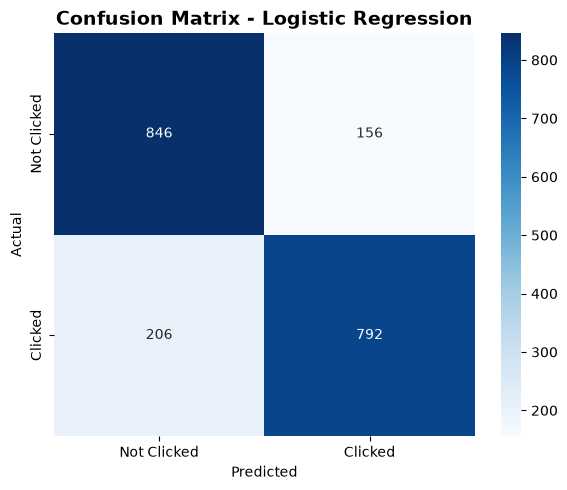

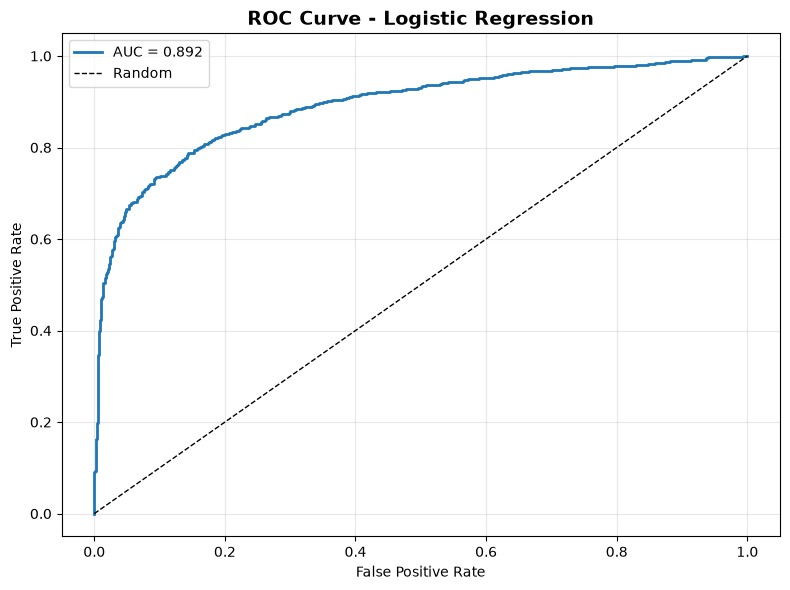

In [5]:
# Model 1: Logistic Regression (Baseline)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

metrics_lr, y_pred_lr, y_pred_proba_lr = evaluate_model(log_reg, X_test, y_test)
print("=== Logistic Regression Performance ===")
for metric, value in metrics_lr.items():
    print(f"{metric}: {value:.4f}")

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_roc_curve(y_test, y_pred_proba_lr, "Logistic Regression")

=== Random Forest Performance ===
Accuracy: 0.8460
Precision: 0.8624
Recall: 0.8226
F1-Score: 0.8421
AUC-ROC: 0.9220


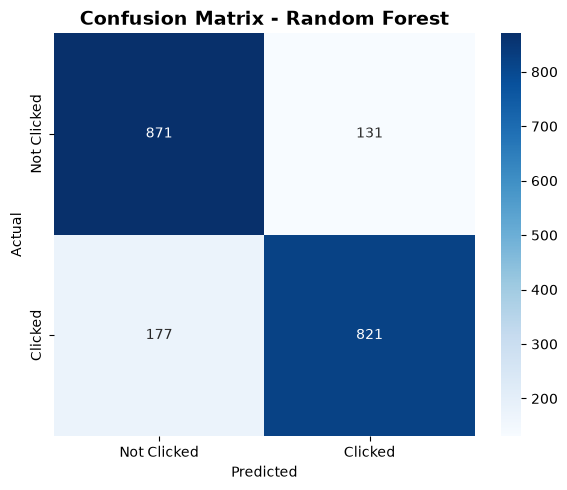

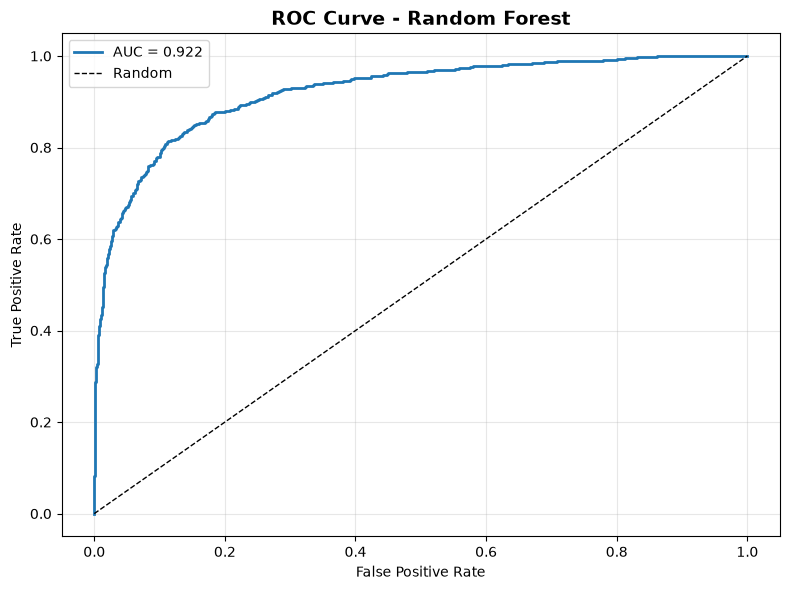

In [6]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

metrics_rf, y_pred_rf, y_pred_proba_rf = evaluate_model(rf, X_test, y_test)
print("=== Random Forest Performance ===")
for metric, value in metrics_rf.items():
    print(f"{metric}: {value:.4f}")

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_roc_curve(y_test, y_pred_proba_rf, "Random Forest")

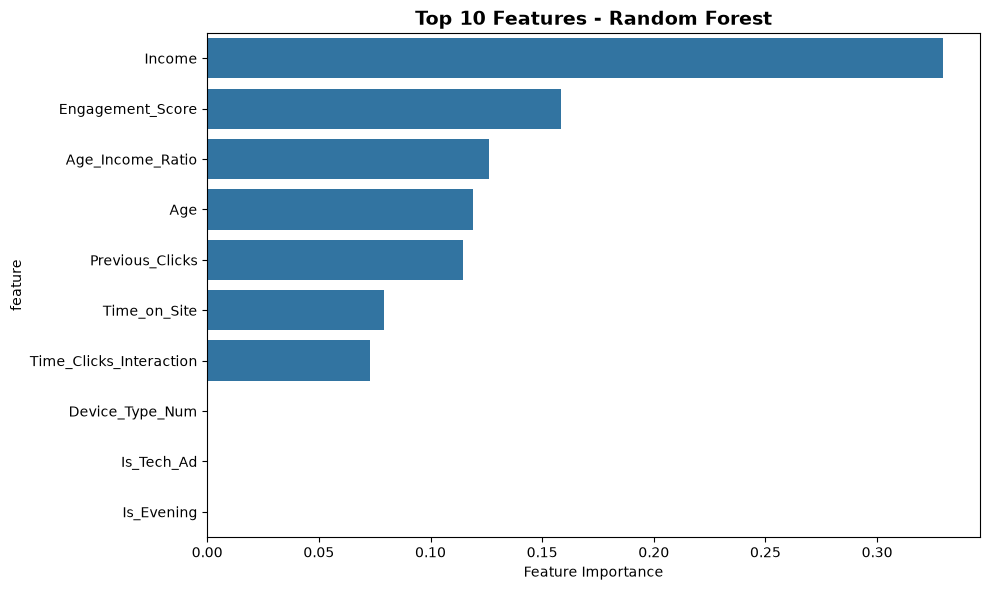

In [7]:
# Feature importance - Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_rf.head(10), x='importance', y='feature')
plt.title('Top 10 Features - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

[LightGBM] [Info] Number of positive: 3991, number of negative: 4009
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498875 -> initscore=-0.004500
[LightGBM] [Info] Start training from score -0.004500
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[40]	training's auc: 0.951707	training's binary_logloss: 0.29403	valid_1's auc: 0.925049	valid_1's binary_logloss: 0.350253
=== LightGBM Performance ===
Accuracy: 0.8490
Precision: 0.8648
Recall: 0.8267
F1-Score: 0.8453
AUC-ROC: 0.9250


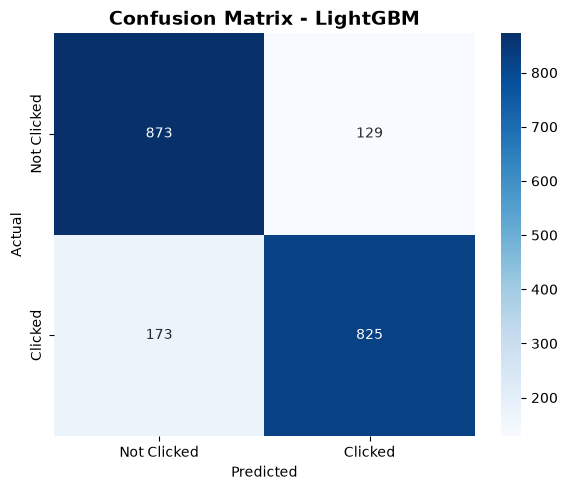

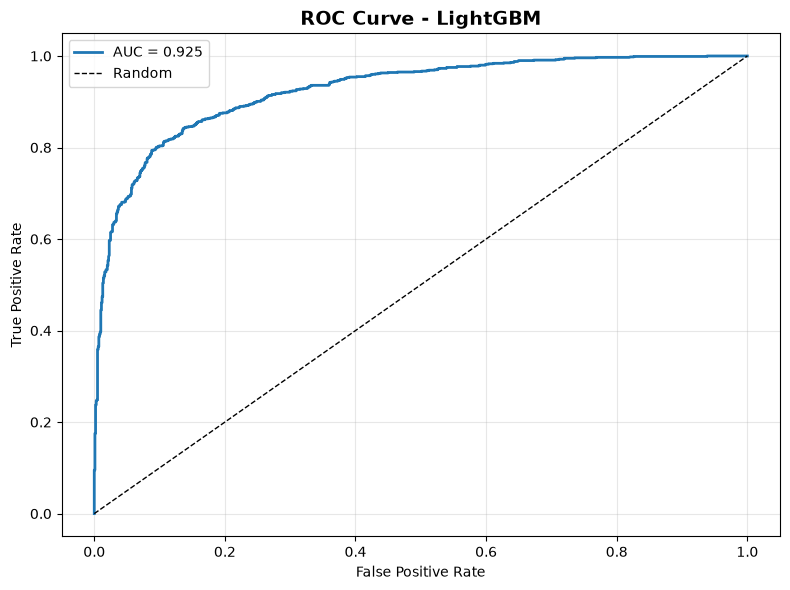

In [8]:
# Model 3: LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train, y_train, 
              eval_set=[(X_train, y_train), (X_test, y_test)],
              eval_metric='auc',
              callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)])

metrics_lgb, y_pred_lgb, y_pred_proba_lgb = evaluate_model(lgb_model, X_test, y_test)
print("=== LightGBM Performance ===")
for metric, value in metrics_lgb.items():
    print(f"{metric}: {value:.4f}")

plot_confusion_matrix(y_test, y_pred_lgb, "LightGBM")
plot_roc_curve(y_test, y_pred_proba_lgb, "LightGBM")

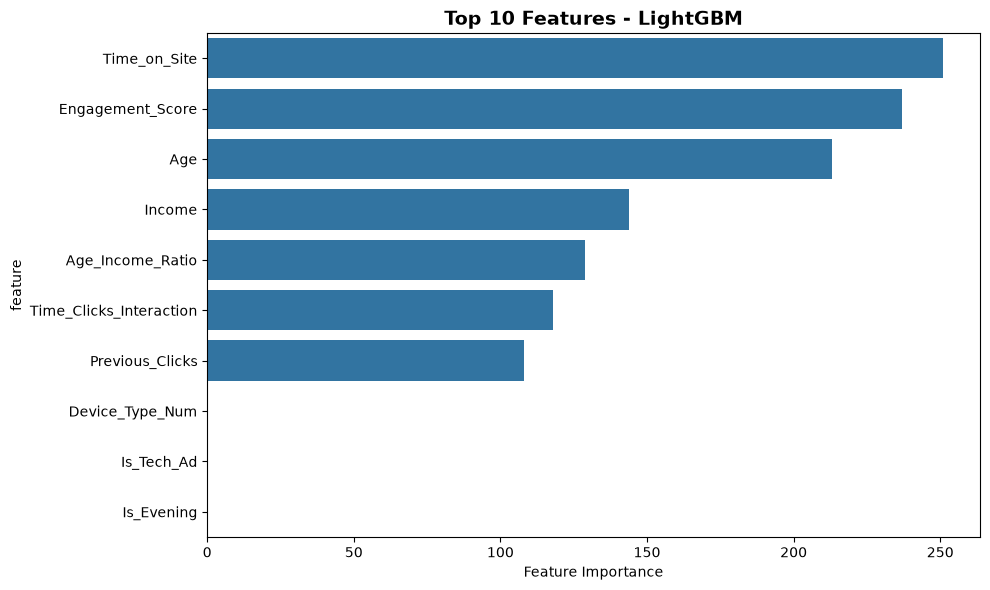

In [9]:
# Feature importance - LightGBM
feature_importance_lgb = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_lgb.head(10), x='importance', y='feature')
plt.title('Top 10 Features - LightGBM', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [10]:
# Hyperparameter tuning for LightGBM
param_grid = {
    'num_leaves': [15, 31, 50],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'min_child_samples': [10, 20, 30]
}

lgb_tune = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    lgb_tune, param_grid, cv=5, scoring='roc_auc', 
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\n=== Best Parameters ===")
print(grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 3991, number of negative: 4009
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498875 -> initscore=-0.004500
[LightGBM] [Info] Start training from score -0.004500

=== Best Parameters ===
{'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Best CV Score: 0.9222


=== Tuned LightGBM Performance ===
Accuracy: 0.8560
Precision: 0.8737
Recall: 0.8317
F1-Score: 0.8522
AUC-ROC: 0.9268


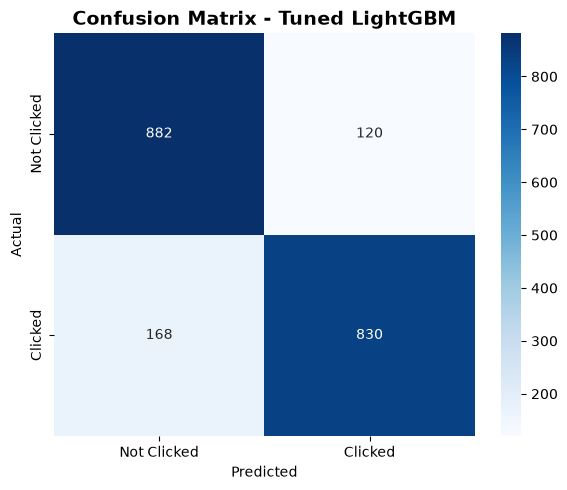

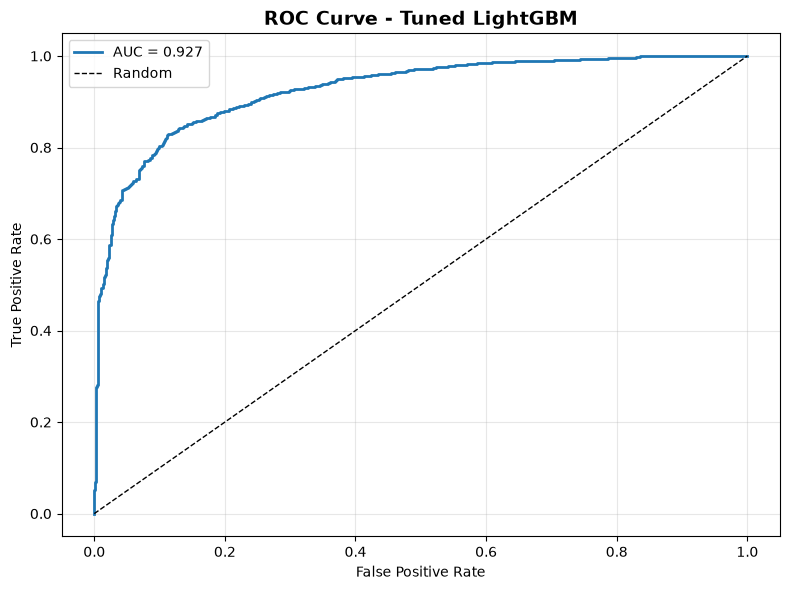

In [11]:
# Evaluate tuned LightGBM
best_lgb = grid_search.best_estimator_
metrics_lgb_tuned, y_pred_lgb_tuned, y_pred_proba_lgb_tuned = evaluate_model(best_lgb, X_test, y_test)

print("=== Tuned LightGBM Performance ===")
for metric, value in metrics_lgb_tuned.items():
    print(f"{metric}: {value:.4f}")

plot_confusion_matrix(y_test, y_pred_lgb_tuned, "Tuned LightGBM")
plot_roc_curve(y_test, y_pred_proba_lgb_tuned, "Tuned LightGBM")

In [12]:
# Compare all models
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'Tuned LightGBM'],
    'Accuracy': [metrics_lr['Accuracy'], metrics_rf['Accuracy'], 
                 metrics_lgb['Accuracy'], metrics_lgb_tuned['Accuracy']],
    'Precision': [metrics_lr['Precision'], metrics_rf['Precision'], 
                  metrics_lgb['Precision'], metrics_lgb_tuned['Precision']],
    'Recall': [metrics_lr['Recall'], metrics_rf['Recall'], 
               metrics_lgb['Recall'], metrics_lgb_tuned['Recall']],
    'F1-Score': [metrics_lr['F1-Score'], metrics_rf['F1-Score'], 
                 metrics_lgb['F1-Score'], metrics_lgb_tuned['F1-Score']],
    'AUC-ROC': [metrics_lr['AUC-ROC'], metrics_rf['AUC-ROC'], 
                metrics_lgb['AUC-ROC'], metrics_lgb_tuned['AUC-ROC']]
})

print("\n=== Model Comparison ===")
print(model_comparison.round(4))


=== Model Comparison ===
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression     0.819     0.8354  0.7936    0.8140   0.8921
1        Random Forest     0.846     0.8624  0.8226    0.8421   0.9220
2             LightGBM     0.849     0.8648  0.8267    0.8453   0.9250
3       Tuned LightGBM     0.856     0.8737  0.8317    0.8522   0.9268


In [13]:
# Compare all models
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM', 'Tuned LightGBM'],
    'Accuracy': [metrics_lr['Accuracy'], metrics_rf['Accuracy'], 
                 metrics_lgb['Accuracy'], metrics_lgb_tuned['Accuracy']],
    'Precision': [metrics_lr['Precision'], metrics_rf['Precision'], 
                  metrics_lgb['Precision'], metrics_lgb_tuned['Precision']],
    'Recall': [metrics_lr['Recall'], metrics_rf['Recall'], 
               metrics_lgb['Recall'], metrics_lgb_tuned['Recall']],
    'F1-Score': [metrics_lr['F1-Score'], metrics_rf['F1-Score'], 
                 metrics_lgb['F1-Score'], metrics_lgb_tuned['F1-Score']],
    'AUC-ROC': [metrics_lr['AUC-ROC'], metrics_rf['AUC-ROC'], 
                metrics_lgb['AUC-ROC'], metrics_lgb_tuned['AUC-ROC']]
})

print("\n=== Model Comparison ===")
print(model_comparison.round(4))


=== Model Comparison ===
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression     0.819     0.8354  0.7936    0.8140   0.8921
1        Random Forest     0.846     0.8624  0.8226    0.8421   0.9220
2             LightGBM     0.849     0.8648  0.8267    0.8453   0.9250
3       Tuned LightGBM     0.856     0.8737  0.8317    0.8522   0.9268


In [14]:
# Save the best model
best_model = best_lgb
joblib.dump(best_model, '../models/ctr_model.pkl')

print("Model saved to 'models/ctr_model.pkl'")

Model saved to 'models/ctr_model.pkl'


In [15]:
# Test prediction function
def predict_click(features):
    """Predict click probability for new data"""
    model = joblib.load('../models/ctr_model.pkl')
    scaler = joblib.load('../models/scaler.pkl')
    
    # Scale features
    features_scaled = features.copy()
    numerical_cols = ['Age', 'Income', 'Time_on_Site', 'Previous_Clicks', 
                      'Engagement_Score', 'Time_Clicks_Interaction', 'Age_Income_Ratio']
    features_scaled[numerical_cols] = scaler.transform(features_scaled[numerical_cols])
    
    # Predict
    proba = model.predict_proba(features_scaled)[:, 1]
    pred = model.predict(features_scaled)
    return pred, proba

In [16]:
# Example prediction
sample_data = pd.DataFrame({
    'Age': [35], 'Income': [70000], 'Time_on_Site': [12.5], 'Previous_Clicks': [25],
    'Device_Type_Num': [1], 'Is_Tech_Ad': [1], 'Is_Male': [1], 'Is_Evening': [1],
    'Engagement_Score': [21.25], 'Is_Active_User': [1], 'Is_High_Income': [0],
    'Time_Clicks_Interaction': [312.5], 'Age_Income_Ratio': [0.5]
})

pred, proba = predict_click(sample_data)
print(f"Sample prediction: {'Click' if pred[0] == 1 else 'No Click'}")
print(f"Click probability: {proba[0]:.2%}")

Sample prediction: Click
Click probability: 84.54%
